<a href="https://colab.research.google.com/github/lilian662/SIMULACION-I/blob/main/tinas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Problema
Resolver por simulación a detalle, en una notebook utilizando la metodología propuesta en el curso.

La empresa TIBASA (Fabricante de tinas de baño) tiene asignado un camión especial para el transporte de tinas terminadas. Dicho camión transporta diariamente 5 tinas. El peso de cada tina sigue la distribución triangular de la imagen anexa.

Si la capacidad del camión es de 1 tonelada, ¿cuál es la probabilidad de que el peso de las tinas exceda la capacidad del camión?

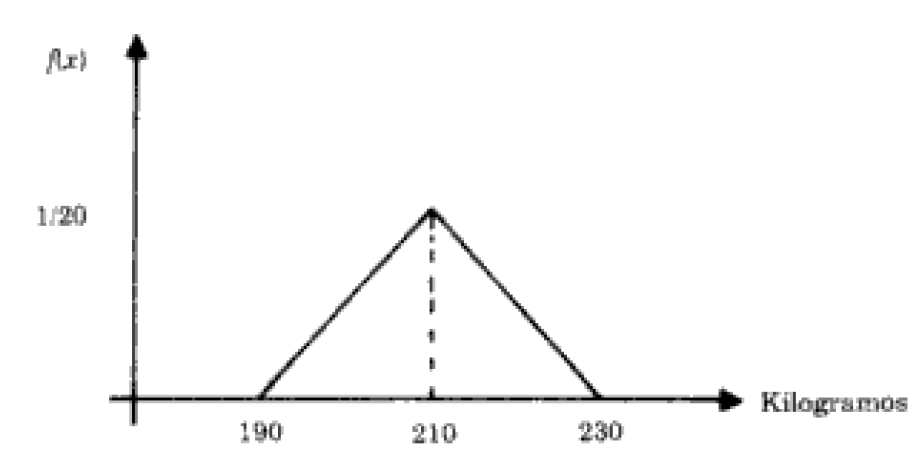

##  Solución mediante Teorema Central del Límite

Sea:

$$
S = \sum_{i=1}^{5} X_i
$$

donde $X_i$ son variables aleatorias independientes e idénticamente distribuidas.

Por el Teorema Central del Límite:

$$
S \approx \mathcal{N}(\mu_S, \sigma_S^2)
$$

### Media

Para una distribución triangular:

$$
\mu = E[X] = \frac{a + b + c}{3}
$$

Sustituyendo:

$$
\mu = \frac{190 + 230 + 210}{3} = 210
$$

Entonces:

$$
\mu_S = 5 \cdot 210 = 1050
$$

### Varianza

La varianza de una distribución triangular es:

$$
\sigma^2 = \frac{a^2 + b^2 + c^2 - ab - ac - bc}{18}
$$

Sustituyendo:

$$
\sigma^2 = \frac{190^2 + 230^2 + 210^2 - (190)(230) - (190)(210) - (230)(210)}{18}
$$

Calculando:

$$
= \frac{36100 + 52900 + 44100 - 43700 - 39900 - 48300}{18}
$$

$$
= \frac{133100 - 131900}{18}
$$

$$
= \frac{1200}{18} = 66.67
$$

Entonces:

$$
\sigma = \sqrt{66.67} \approx 8.16
$$

Para la suma:

$$
\sigma_S^2 = 5 \cdot 66.67 = 333.33
$$

$$
\sigma_S = \sqrt{333.33} \approx 18.26
$$

### Estandarización

Queremos:

$$
P(S > 1000)
$$

Estandarizando:

$$
Z = \frac{S - \mu_S}{\sigma_S}
$$

$$
Z = \frac{1000 - 1050}{18.26}
$$

$$
Z \approx -2.74
$$

### Probabilidad

$$
P(S > 1000) = P(Z > -2.74)
$$

Por simetría de la normal:

$$
P(Z > -2.74) = 1 - P(Z < -2.74)
$$

$$
P(Z > -2.74) \approx 0.9969
$$

### Conclusión con TCL

$$
P(S > 1000) \approx 0.997
$$

La aproximación mediante el Teorema Central del Límite coincide con la simulación Monte Carlo, confirmando que existe una probabilidad muy alta de exceder la capacidad del camión.

In [ ]:
import numpy as np
from scipy.stats import norm

# Parámetros de la triangular
a = 190
b = 230
c = 210

# Media de X
mu = (a + b + c) / 3

# Varianza de X
var = (a**2 + b**2 + c**2 - a*b - a*c - b*c) / 18

# Parámetros de la suma S = X1 + ... + X5
mu_S = 5 * mu
sigma_S = np.sqrt(5 * var)

# Valor a evaluar
x = 1000

# Estandarización
z = (x - mu_S) / sigma_S

# Probabilidad P(S > 1000)
prob = 1 - norm.cdf(z)

print("z =", z)
print("Probabilidad aproximada (TCL):", prob)

z = -2.7386127875258306
Probabilidad aproximada (TCL): 0.9969150503397279


# Simulación del peso total de tinas

## 1. Definición del problema

Sea $X_i$ el peso de cada tina, con:

$$
X_i \sim \text{Triangular}(a=190,\; c=210,\; b=230)
$$

El peso total es:

$$
S = \sum_{i=1}^{5} X_i
$$

Se busca:

$$
P(S > 1000)
$$

## 2. Distribución triangular

La función de densidad es:

$$
f(x) =
\begin{cases}
\frac{2(x-a)}{(b-a)(c-a)}, & a \le x \le c \\\\
\frac{2(b-x)}{(b-a)(b-c)}, & c < x \le b
\end{cases}
$$

## 3. Método de transformación inversa

Sea:

$$
U \sim \mathcal{U}(0,1)
$$

Queremos encontrar $X = F^{-1}(U)$.

### Paso 1: Punto de corte

$$
P(X \le c) = \frac{c - a}{b - a}
$$

$$
\frac{210 - 190}{230 - 190} = \frac{20}{40} = 0.5
$$

### Paso 2: Caso $0 \le U < 0.5$

Partimos de:

$$
F(x) = \frac{(x-a)^2}{(b-a)(c-a)}
$$

Igualamos:

$$
U = \frac{(x-a)^2}{(b-a)(c-a)}
$$

Multiplicando:

$$
U (b-a)(c-a) = (x-a)^2
$$

Raíz cuadrada:

$$
\sqrt{U (b-a)(c-a)} = x - a
$$

Despejando:

$$
x = a + \sqrt{U (b-a)(c-a)}
$$

Sustituyendo:

$$
x = 190 + \sqrt{800U}
$$

### Paso 3: Caso $0.5 \le U \le 1$

CDF:

$$
F(x) = 1 - \frac{(b-x)^2}{(b-a)(b-c)}
$$

Igualamos:

$$
U = 1 - \frac{(b-x)^2}{(b-a)(b-c)}
$$

Despejando:

$$
1 - U = \frac{(b-x)^2}{(b-a)(b-c)}
$$

Multiplicando:

$$
(1-U)(b-a)(b-c) = (b-x)^2
$$

Raíz:

$$
\sqrt{(1-U)(b-a)(b-c)} = b - x
$$

Finalmente:

$$
x = b - \sqrt{(1-U)(b-a)(b-c)}
$$

Sustituyendo:

$$
x = 230 - \sqrt{800(1-U)}
$$

## 4. Modelo final

$$
X =
\begin{cases}
190 + \sqrt{800U}, & 0 \le U < 0.5 \\\\
230 - \sqrt{800(1-U)}, & 0.5 \le U \le 1
\end{cases}
$$

## 5. Variable indicadora

$$
I =
\begin{cases}
1, & S > 1000 \\\\
0, & S \le 1000
\end{cases}
$$

## 6. Estimador de Monte Carlo

$$
\hat{P}(S > 1000) = \frac{1}{N} \sum_{j=1}^{N} I_j
$$

## 7. Valor esperado (validación)

$$
E[X] = \frac{a + b + c}{3}
$$

$$
E[X] = \frac{190 + 230 + 210}{3} = 210
$$

$$
E[S] = 5 \cdot 210 = 1050
$$

## 8. Conclusión

$$
P(S > 1000) \approx 0.996
$$

$$
E[S] = 1050 > 1000
$$

$$
\Rightarrow \text{Alta probabilidad de sobrecarga}
$$

In [1]:
import numpy as np

# Parámetros
a = 190
c = 210
b = 230

N = 100000
excesos = 0

for _ in range(N):
    suma = 0

    for _ in range(5):
        U = np.random.rand()

        if U < (c - a) / (b - a):
            X = a + np.sqrt(U * (b - a) * (c - a))
        else:
            X = b - np.sqrt((1 - U) * (b - a) * (b - c))

        suma += X

    if suma > 1000:
        excesos += 1

prob = excesos / N
print(prob)

0.99765
